<a href="https://colab.research.google.com/github/Lorenzo-v8/Analisis-Default-of-credit-card-clients/blob/main/Default_of_Credit_Card_clients.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import files
uploaded = files.upload()


Saving default+of+credit+card+clients.zip to default+of+credit+card+clients.zip


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
plt.rcParams["figure.figsize"] = (6, 3)
plt.rcParams["figure.dpi"] = 80
from matplotlib.colors import ListedColormap
from sklearn.preprocessing import PowerTransformer, StandardScaler, OneHotEncoder
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split, cross_val_predict, StratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    roc_auc_score,
    average_precision_score,
    recall_score,
    f1_score,
    precision_score
)

In [ ]:
# Descarga el ZIP desde la web de UCI directo a Colab (-q = sin mostrar progreso de descarga)
!wget -q "https://archive.ics.uci.edu/static/public/350/default+of+credit+card+clients.zip"
# Descomprime el ZIP y deja el .xls en la carpeta actual (-o = sobrescribe, -q = osea "quiet" silencioso, para que no se muestre el progreso de descarga nuevamente)
!unzip -o -q default+of+credit+card+clients.zip

In [ ]:
# Lee el header=1 porque la fila 0 tiene etiquetas X1...X23 y los nombres reales están en la fila 1
df = pd.read_excel("default of credit card clients.xls", header=1)
# Renombramos columnas: la variable objetivo y PAY_0 (para que sea consistente con PAY_2...PAY_6)
df = df.rename(columns={"default payment next month": "default", "PAY_0": "PAY_1"})
# Guarda el DataFrame como CSV, sin la columna de índice, porque era un xls
df.to_csv("credit_default.csv", index=False)
# Corremos las primeras 5 filas
df.head()

,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_1,PAY_2,PAY_3,PAY_4,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default
0,1,20000,2,2,1,24,2,2,-1,-1,...,0,0,0,0,689,0,0,0,0,1
1,2,120000,2,2,2,26,-1,2,0,0,...,3272,3455,3261,0,1000,1000,1000,0,2000,1
2,3,90000,2,2,2,34,0,0,0,0,...,14331,14948,15549,1518,1500,1000,1000,1000,5000,0
3,4,50000,2,2,1,37,0,0,0,0,...,28314,28959,29547,2000,2019,1200,1100,1069,1000,0
4,5,50000,1,2,1,57,-1,0,-1,0,...,20940,19146,19131,2000,36681,10000,9000,689,679,0


In [ ]:
# Dimensiones: (filas, columnas). Esperable: (30000, 25)
df.shape
# Tipos de dato y cantidad de no-nulos por columna: para ver si algo está mal tipado
df.info()
# Cantidad de valores faltantes por columna
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 25 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   ID         30000 non-null  int64
 1   LIMIT_BAL  30000 non-null  int64
 2   SEX        30000 non-null  int64
 3   EDUCATION  30000 non-null  int64
 4   MARRIAGE   30000 non-null  int64
 5   AGE        30000 non-null  int64
 6   PAY_1      30000 non-null  int64
 7   PAY_2      30000 non-null  int64
 8   PAY_3      30000 non-null  int64
 9   PAY_4      30000 non-null  int64
 10  PAY_5      30000 non-null  int64
 11  PAY_6      30000 non-null  int64
 12  BILL_AMT1  30000 non-null  int64
 13  BILL_AMT2  30000 non-null  int64
 14  BILL_AMT3  30000 non-null  int64
 15  BILL_AMT4  30000 non-null  int64
 16  BILL_AMT5  30000 non-null  int64
 17  BILL_AMT6  30000 non-null  int64
 18  PAY_AMT1   30000 non-null  int64
 19  PAY_AMT2   30000 non-null  int64
 20  PAY_AMT3   30000 non-null  int64
 21  PAY_AMT4   3

,0
ID,0
LIMIT_BAL,0
SEX,0
EDUCATION,0
MARRIAGE,0
AGE,0
PAY_1,0
PAY_2,0
PAY_3,0
PAY_4,0


In [ ]:
# Estadísticas de cada columna (media, desvío, mín, máx, cuartiles); t es para transponer la tabla, así las 25 variables quedan como filas y es más fácil de leer.
df.describe().T

,count,mean,std,min,25%,50%,75%,max
ID,30000.0,15000.500000,8660.398374,1.0,7500.75,15000.5,22500.25,30000.0
LIMIT_BAL,30000.0,167484.322667,129747.661567,10000.0,50000.00,140000.0,240000.00,1000000.0
SEX,30000.0,1.603733,0.489129,1.0,1.00,2.0,2.00,2.0
EDUCATION,30000.0,1.853133,0.790349,0.0,1.00,2.0,2.00,6.0
MARRIAGE,30000.0,1.551867,0.521970,0.0,1.00,2.0,2.00,3.0
AGE,30000.0,35.485500,9.217904,21.0,28.00,34.0,41.00,79.0
PAY_1,30000.0,-0.016700,1.123802,-2.0,-1.00,0.0,0.00,8.0
PAY_2,30000.0,-0.133767,1.197186,-2.0,-1.00,0.0,0.00,8.0
PAY_3,30000.0,-0.166200,1.196868,-2.0,-1.00,0.0,0.00,8.0
PAY_4,30000.0,-0.220667,1.169139,-2.0,-1.00,0.0,0.00,8.0


In [ ]:
# Limpieza de categorías no documentadas
df["EDUCATION"] = df["EDUCATION"].replace({0: 4, 5: 4, 6: 4})
df["MARRIAGE"] = df["MARRIAGE"].replace({0: 3})

# ID no aporta información para el analisis
df = df.drop(columns="ID")

# Verificación
print(df["EDUCATION"].value_counts().sort_index())
print(df["MARRIAGE"].value_counts().sort_index())
print(df["default"].value_counts(normalize=True))

EDUCATION
1    10585
2    14030
3     4917
4      468
Name: count, dtype: int64
MARRIAGE
1    13659
2    15964
3      377
Name: count, dtype: int64
default
0    0.7788
1    0.2212
Name: proportion, dtype: float64


In [ ]:
# Tasa de default según el estado de pago del último mes (PAY_1)
df.groupby("PAY_1")["default"].agg(["mean", "count"]).round(3)

,mean,count
PAY_1,,
-2,0.132,2759
-1,0.168,5686
0,0.128,14737
1,0.339,3688
2,0.691,2667
3,0.758,322
4,0.684,76
5,0.500,26
6,0.545,11


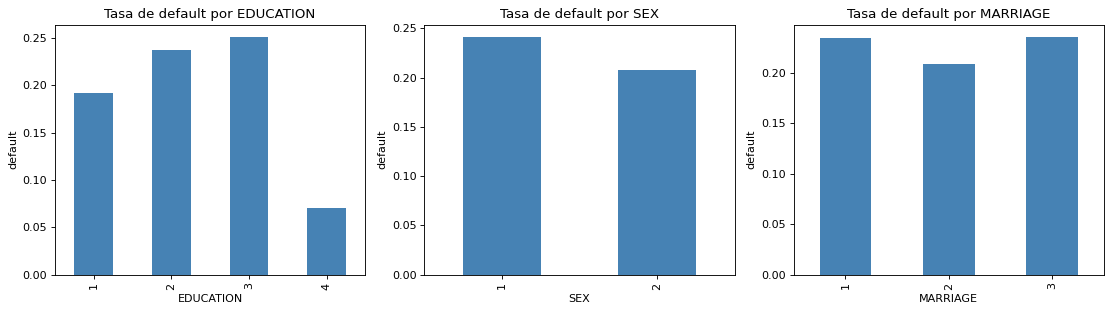

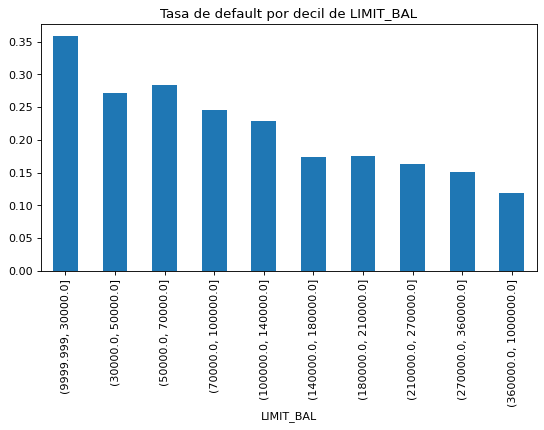

In [ ]:
# 2) Tasa de default por EDUCATION, SEX y MARRIAGE
fig, axes = plt.subplots(1, 3, figsize=(14, 4))                                  #crea una fila con 3 gráficos lado a lado.
for ax, col in zip(axes, ["EDUCATION", "SEX", "MARRIAGE"]):
    df.groupby(col)["default"].mean().plot(kind="bar", ax=ax, color="steelblue") #tasa de default por categoría (como default es 0/1, el promedio es la proporción).
    ax.set_title(f"Tasa de default por {col}")
    ax.set_ylabel("default")
plt.tight_layout()
plt.show()

# Default por tramos de límite de crédito (deciles)
df.groupby(pd.qcut(df["LIMIT_BAL"], 10),observed=True)["default"].mean().plot(kind="bar", figsize=(8, 4)) # divide LIMIT_BAL (variable continua) en 10 tramos con la misma cantidad de clientes cada uno (deciles).
plt.title("Tasa de default por decil de LIMIT_BAL")
plt.show()

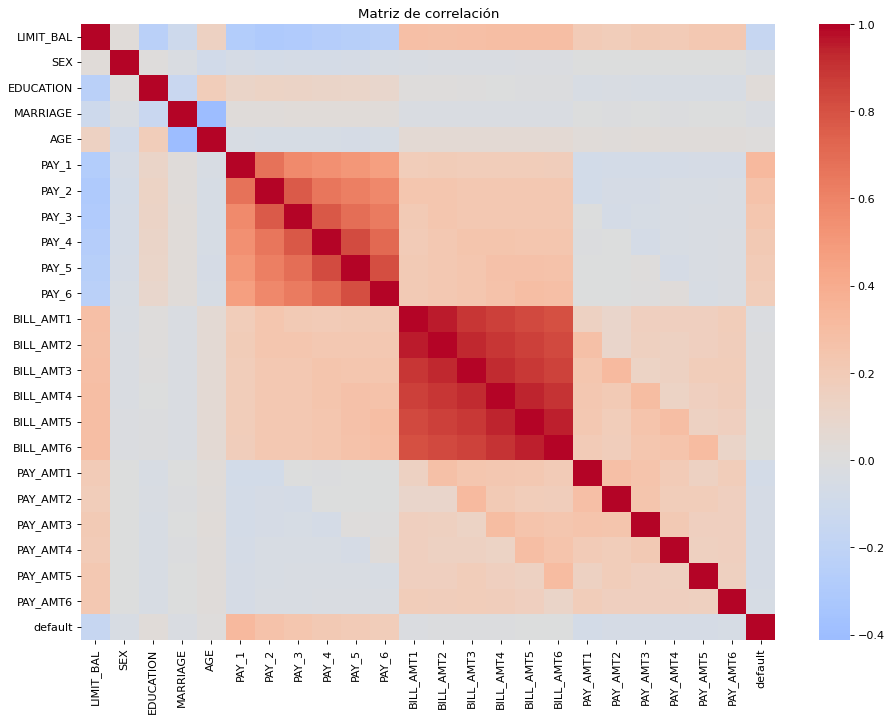

In [ ]:
# 3) Matriz de correlación: justifica PCA (bloques de BILL_AMT muy correlacionados)
plt.figure(figsize=(14, 10))
sns.heatmap(df.corr(), cmap="coolwarm", center=0, annot=False)
plt.title("Matriz de correlación")
plt.show()


In [ ]:
# Correlación de cada variable con default, ordenada
#mayor valor de la variable, más probabilidad de default.
#menor valor, menos probabilidad (se espera en LIMIT_BAL).
#Cerca de 0: sin relación lineal.
df.corr()["default"].drop("default").sort_values(ascending=False)

,default
PAY_1,0.324794
PAY_2,0.263551
PAY_3,0.235253
PAY_4,0.216614
PAY_5,0.204149
PAY_6,0.186866
EDUCATION,0.033842
AGE,0.013890
BILL_AMT6,-0.005372
BILL_AMT5,-0.006760


In [ ]:
# Separar variables y objetivo
X = df.drop(columns="default")
y = df["default"]

# Split estratificado para mantener el ~22% de defaults en train y test
#80% entrenamiento, 20% prueba. stratify=y mantiene la misma proporción de defaults (~22%) en ambos. random_state=42 hace que el corte sea reproducible.
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

# Grupos de columnas
cat_cols = ["SEX", "EDUCATION", "MARRIAGE"]
pay_cols = [f"PAY_{i}" for i in range(1, 7)]
money_cols = ["LIMIT_BAL", "AGE"] + [f"BILL_AMT{i}" for i in range(1, 7)] + [f"PAY_AMT{i}" for i in range(1, 7)]

# Preprocesamiento:
# - Yeo-Johnson corrige colas largas y admite negativos
# - StandardScaler sobre pay_cols: media 0, desvío 1.
# - Categóricas a one-hot porque (PCA no acepta matrices dispersas)
preprocess = ColumnTransformer([
    ("money", PowerTransformer(method="yeo-johnson"), money_cols),
    ("pay", StandardScaler(), pay_cols),
    ("cat", OneHotEncoder(sparse_output=False), cat_cols),
])

# Modelo A: Bayes ingenuo sin PCA
nb = Pipeline([("prep", preprocess), ("nb", GaussianNB())])

# Modelo B: PCA reteniendo 95% de la varianza + Bayes ingenuo
#aca pca elige solo la cantidad de componentes necesaria para retener el 95% de la varianza.
pca_nb = Pipeline([("prep", preprocess), ("pca", PCA(n_components=0.95)), ("nb", GaussianNB())])

# Entrenar y evaluar ambos
for name, model in [("NB sin PCA", nb), ("PCA + NB", pca_nb)]:
    model.fit(X_train, y_train)
    proba = model.predict_proba(X_test)[:, 1]
    pred = model.predict(X_test)
    print(f"{name}: ROC-AUC={roc_auc_score(y_test, proba):.3f} | "
          f"PR-AUC={average_precision_score(y_test, proba):.3f} | "
          f"Recall default={recall_score(y_test, pred):.3f}")
#metricas del output
          #ROC-AUC: qué tan bien separa clases en todos los umbrales.
          #PR-AUC: más informativa con clases desbalanceadas.
          #Recall default: de los defaults reales, cuántos detecta.


# Cuántas componentes quedaron
print("Componentes PCA:", pca_nb.named_steps["pca"].n_components_)

NB sin PCA: ROC-AUC=0.744 | PR-AUC=0.481 | Recall default=0.523
PCA + NB: ROC-AUC=0.708 | PR-AUC=0.407 | Recall default=0.339
Componentes PCA: 17


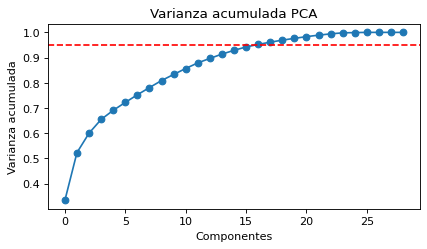

In [ ]:
# Varianza acumulada con todas las componentes
X_prep = preprocess.fit_transform(X_train)
pca_full = PCA().fit(X_prep)
plt.figure(figsize=(6, 3))
plt.plot(np.cumsum(pca_full.explained_variance_ratio_), marker="o")
plt.axhline(0.95, color="red", ls="--")
plt.xlabel("Componentes"); plt.ylabel("Varianza acumulada")
plt.title("Varianza acumulada PCA")
plt.show()


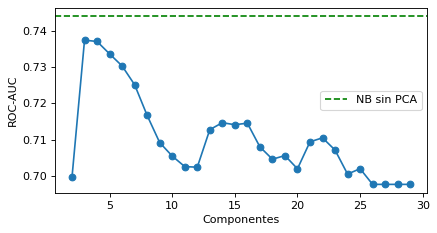

In [ ]:
#prueba PCA + Bayes ingenuo con cada cantidad de componentes posible y grafica el ROC-AUC de cada una, comparándolo contra el modelo sin PCA.
resultados = []
for k in range(2, X_prep.shape[1] + 1):
    m = Pipeline([("prep", preprocess), ("pca", PCA(n_components=k)), ("nb", GaussianNB())])
    m.fit(X_train, y_train)
    resultados.append((k, roc_auc_score(y_test, m.predict_proba(X_test)[:, 1])))

ks, aucs = zip(*resultados)
plt.figure(figsize=(6, 3))
plt.plot(ks, aucs, marker="o")
plt.axhline(0.744, color="green", ls="--", label="NB sin PCA")
plt.xlabel("Componentes"); plt.ylabel("ROC-AUC")
plt.legend(); plt.show()

Umbral óptimo (F1 en train CV): 0.39


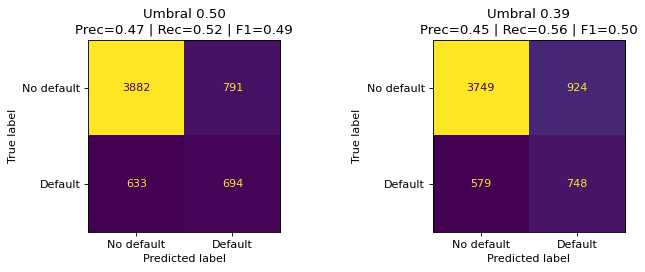

In [ ]:
# 1) Probabilidades out-of-fold en train (el modelo nunca ve la fila que predice)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
proba_cv = cross_val_predict(nb, X_train, y_train, cv=cv, method="predict_proba")[:, 1]

#Barrido de umbrales maximizando F1 en train
umbrales = np.arange(0.05, 0.96, 0.01)
f1s = [f1_score(y_train, proba_cv >= t) for t in umbrales]
t_best = umbrales[np.argmax(f1s)]
print(f"Umbral óptimo (F1 en train CV): {t_best:.2f}")

# 3) Evaluación en test: umbral 0.5 vs. umbral óptimo
nb.fit(X_train, y_train)
proba_test = nb.predict_proba(X_test)[:, 1]

fig, axes = plt.subplots(1, 2, figsize=(9, 3.5))
for ax, t in zip(axes, [0.5, t_best]):
    pred = proba_test >= t
    ConfusionMatrixDisplay(confusion_matrix(y_test, pred), display_labels=["No default", "Default"]).plot(ax=ax, colorbar=False)
    ax.set_title(f"Umbral {t:.2f}\nPrec={precision_score(y_test, pred):.2f} | Rec={recall_score(y_test, pred):.2f} | F1={f1_score(y_test, pred):.2f}")
plt.tight_layout()
plt.show()